In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
!pip install yfinance

In [3]:
import yfinance as yf
import pandas as pd

In [4]:
## download stock data

df = yf.download('RELIANCE.NS', start='2023-01-01', end = '2024-01-01')

### Show the data

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1175.889648,1177.304802,1163.244669,1164.066352,5316175
2023-01-03,1167.284668,1174.565828,1163.062148,1170.936659,7658932
2023-01-04,1149.709595,1169.110728,1147.632506,1167.261851,9264891
2023-01-05,1147.655273,1157.858026,1143.067494,1151.969199,13637099
2023-01-06,1158.086304,1163.130627,1149.595501,1153.407240,6349597


### **Calculation of Daily Return**

In [7]:
### Calculate daily returns
df["Daily_Returns"] = df["Close"].pct_change()

### **Volatility (risk factor)**

In [9]:
### Measure the volatility (risk factor)
## Volatility means how unstable the stock is.

volatility = df["Daily_Returns"].std()
print(volatility)

0.01097274453174462


In [10]:
### Convert the Volatilty for a year
### Since the stock makert only opens for 252 days in an year. this is the reason we multiply the daily volatility with sqaure root of 252
annual_vol = volatility* np.sqrt(252)
print(f"volatility : {volatility: .4f}")
print(f"annual_vol : {annual_vol: .4f}")

volatility :  0.0110
annual_vol :  0.1742


### **Rolling volatility (the moving window)**

In [14]:
### To identify "regime shifts." If the line on a chart goes up, the market is becoming more uncertain and risky.

## Calculate the 21 day rolling colatility for 1 month (21 days)

rolling_vol = df['Daily_Returns'].rolling(window = 21).std()

In [15]:
print(f"rolling_vol: {rolling_vol.iloc[-1]:.4f}")

rolling_vol: 0.0087


### Comparing Volatility across different timeframes

In [17]:
## Intraday Volatility: Using 1-minute or 5-minute data (for day trading).

## Daily Volatility: For general swing trading.

## Monthly Volatility: For long-term "buy and hold" investing.

Short_term_rolling_vol = df['Daily_Returns'].rolling(window = 5).std()

## Calculation of Volatilty on Quaterly basius
Medium_term_rolling_vol = df['Daily_Returns'].rolling(window = 63).std()

## Calculation of Long Term Volatility on yearly basis

annual_vol = volatility* np.sqrt(252)

In [18]:
print(f"Short_term_rolling_vol: {Short_term_rolling_vol.iloc[-1]:.4f}")
print(f"Medium_term_rolling_vol: {Medium_term_rolling_vol.iloc[-1]:.4f}")
print(f"annual_vol: {annual_vol:.4f}")

Short_term_rolling_vol: 0.0059
Medium_term_rolling_vol: 0.0089
annual_vol: 0.1742


### **Risk Adjusted Returns (The Sharpe Ratio)**

In [21]:
## Calculate Daily Stats

mean_return =df["Daily_Returns"].mean()

## Calculate Daily Sharpe

Daily_sharpe = mean_return / df["Daily_Returns"].std()

## Annualize sharpe (252 days)

Annualized_sharpe = Daily_sharpe * np.sqrt(252)

print(f"Annualized Sharpe Ratio: {Annualized_sharpe:0.4f}")

Annualized Sharpe Ratio: 0.6033


#### **Sharpe Ratio Benchmarks (accepted in finance)**
- < 1.0: Sub-optimal — returns aren’t compensating well for risk taken.
- 1.0 – 1.99: Good — acceptable risk-adjusted performance that’s solid in most markets.
- 2.0 – 2.99: Very good — strong performance with controlled volatility.
- ≥ 3.0: Excellent — outstanding risk-adjusted returns (rare and hard to sustain)

In [23]:
#### best and worst trading day

Best_Day = df['Daily_Returns'].idxmax()
Worst_Day = df['Daily_Returns'].idxmin()
print(f"Best_Day = {Best_Day}")
print(f"Worst_Day = {Worst_Day} ")

### Check how much it moved
df.loc[[Best_Day, Worst_Day]], [['Close','Daily_Returns']]

Best_Day = 2023-03-31 00:00:00
Worst_Day = 2023-07-21 00:00:00 


(Price             Close         High          Low         Open      Volume  \
 Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS   
 Date                                                                         
 2023-03-31  1064.116455  1069.777071  1029.262976  1029.399903    28171201   
 2023-07-21  1255.613525  1293.275701  1248.120695  1290.357730    30249238   
 
 Price      Daily_Returns  
 Ticker                    
 Date                      
 2023-03-31      0.043115  
 2023-07-21     -0.030956  ,
 [['Close', 'Daily_Returns']])

### **Visualization**

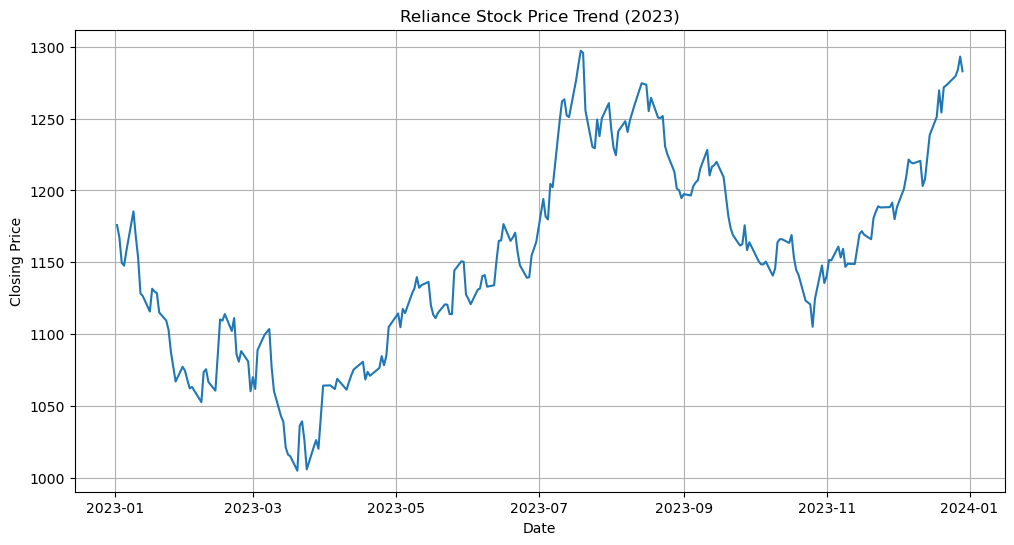

In [34]:
### Stock Price Trend

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'])
plt.title("Reliance Stock Price Trend (2023)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

### 📊 Interpretation: Stock Price Trend

The price trend shows the overall direction of Reliance stock during 2023. 
An upward trend indicates bullish market sentiment, while downward phases suggest temporary corrections or broader market pressure.

Key Observation:
- The stock exhibited periods of growth followed by consolidation.
- No extreme crash-like behavior was observed during the period.
- The general movement reflects moderate stability with normal market fluctuations.

This gives context for the volatility and risk metrics calculated later.

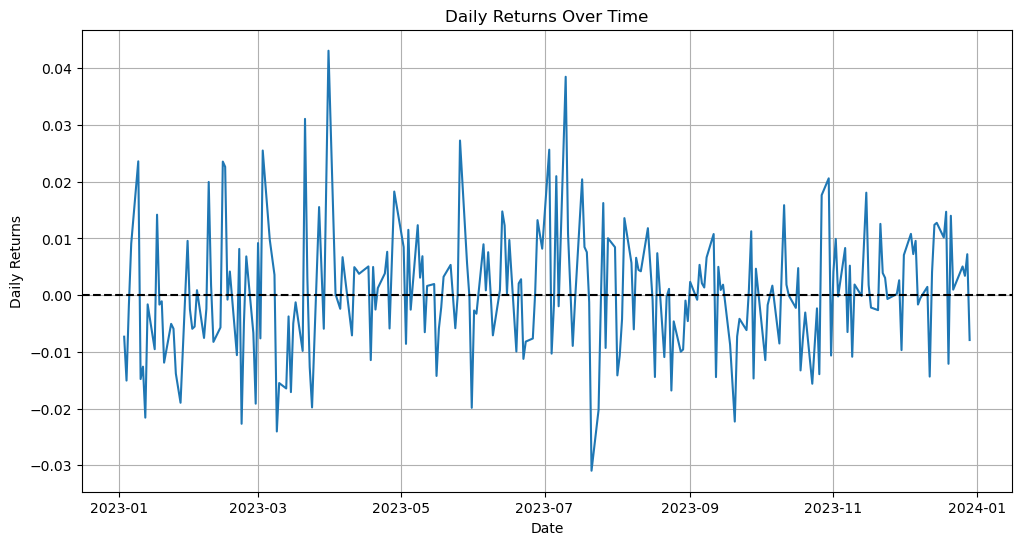

In [37]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Daily_Returns'])
plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.axhline(0, color='black', linestyle='--')
plt.grid(True)
plt.show()

### 📉 Interpretation: Daily Returns

The daily returns chart highlights short-term fluctuations in stock performance.

Key Observation:
- Most daily returns are clustered around zero, indicating normal market movement.
- Occasional sharp spikes represent high volatility days driven by news, earnings announcements, or market-wide movements.
- The presence of both positive and negative spikes confirms the natural risk-return tradeoff in equity markets.

This visualization helps identify unstable periods and supports volatility analysis.

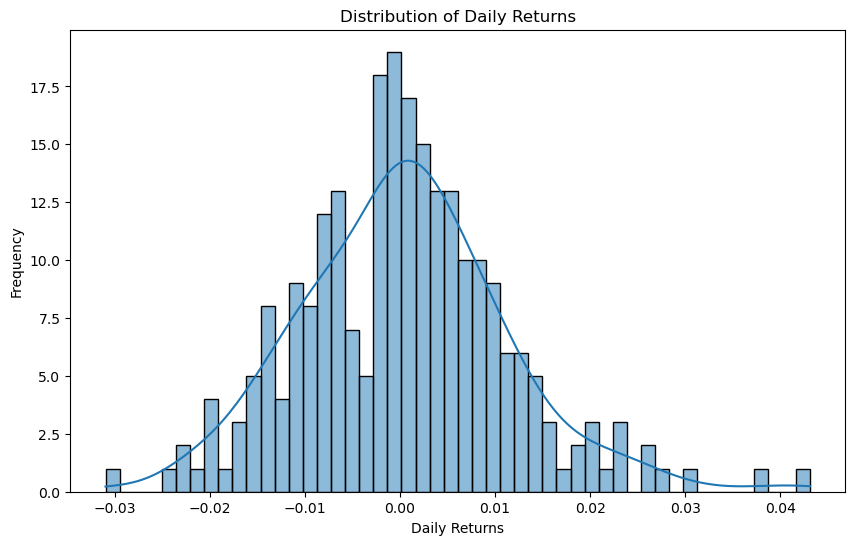

In [40]:
plt.figure(figsize=(10,6))
sns.histplot(df['Daily_Returns'].dropna(), bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.show()

### 📊 Interpretation: Distribution of Returns

The histogram shows how daily returns are distributed over time.

Key Observation:
- The majority of returns lie within a narrow range, suggesting controlled volatility.
- Extreme values (tails) represent rare but impactful market movements.
- The distribution appears approximately centered around zero, which is typical for stock returns.

Understanding the shape of the distribution helps evaluate risk characteristics such as skewness and the probability of extreme losses.

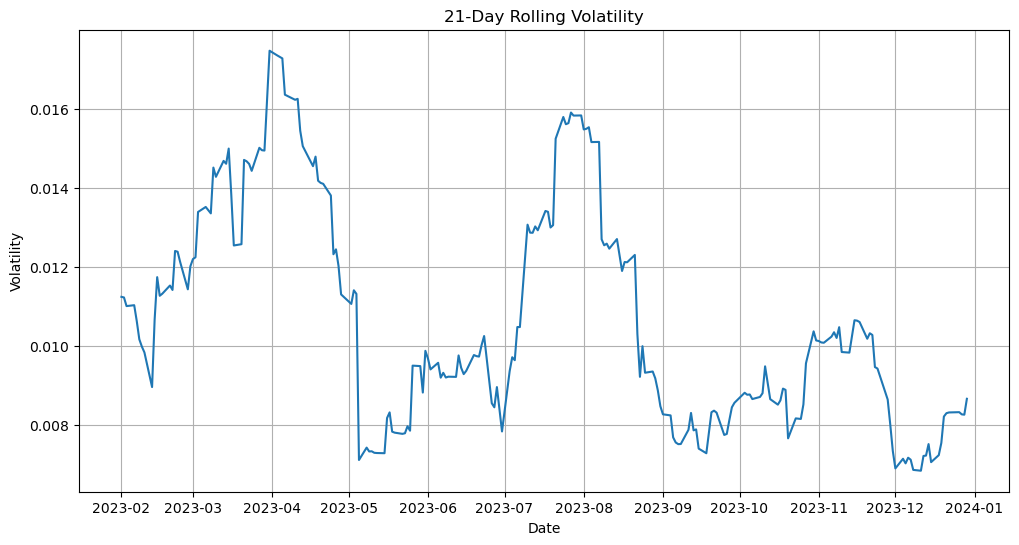

In [43]:
rolling_vol = df['Daily_Returns'].rolling(window=21).std()

plt.figure(figsize=(12,6))
plt.plot(df.index, rolling_vol)
plt.title("21-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

### 📈 Interpretation: Rolling Volatility (21-Day)

The 21-day rolling volatility measures short-term risk trends over approximately one trading month.

Key Observation:
- Rising volatility indicates increasing uncertainty or market stress.
- Falling volatility suggests stabilizing market conditions.
- Temporary volatility spikes may align with economic events or earnings announcements.

This helps identify regime shifts and periods of elevated market risk.

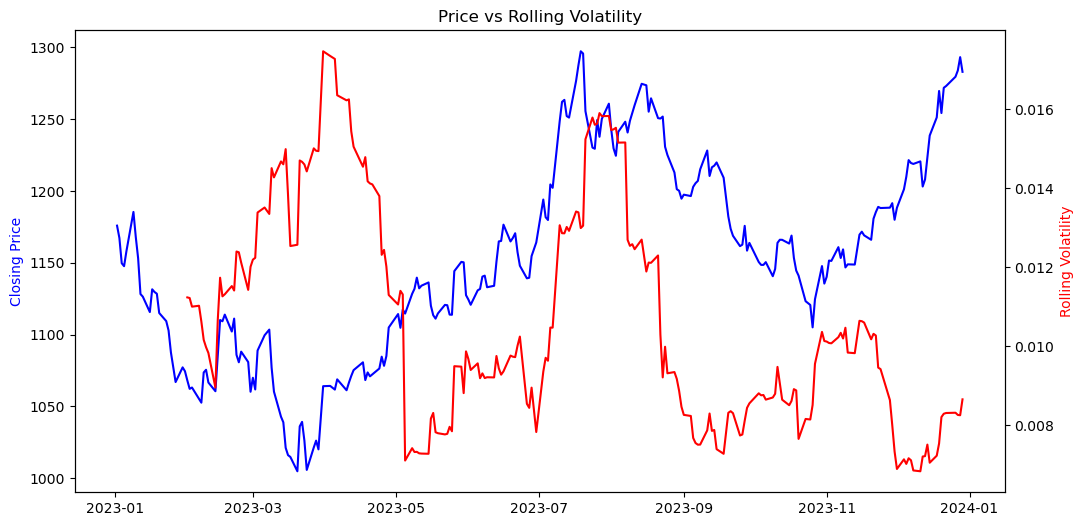

In [46]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df.index, df['Close'], color='blue')
ax1.set_ylabel('Closing Price', color='blue')

ax2 = ax1.twinx()
ax2.plot(df.index, rolling_vol, color='red')
ax2.set_ylabel('Rolling Volatility', color='red')

plt.title("Price vs Rolling Volatility")
plt.show()

### 📊 Interpretation: Price vs Volatility Relationship

This chart compares price movement with rolling volatility.

Key Observation:
- Volatility tends to increase during price declines, reflecting investor uncertainty.
- During stable or upward trends, volatility generally remains lower.
- This inverse relationship is consistent with typical equity market behavior.

This analysis highlights how risk and return dynamics interact in real market conditions.

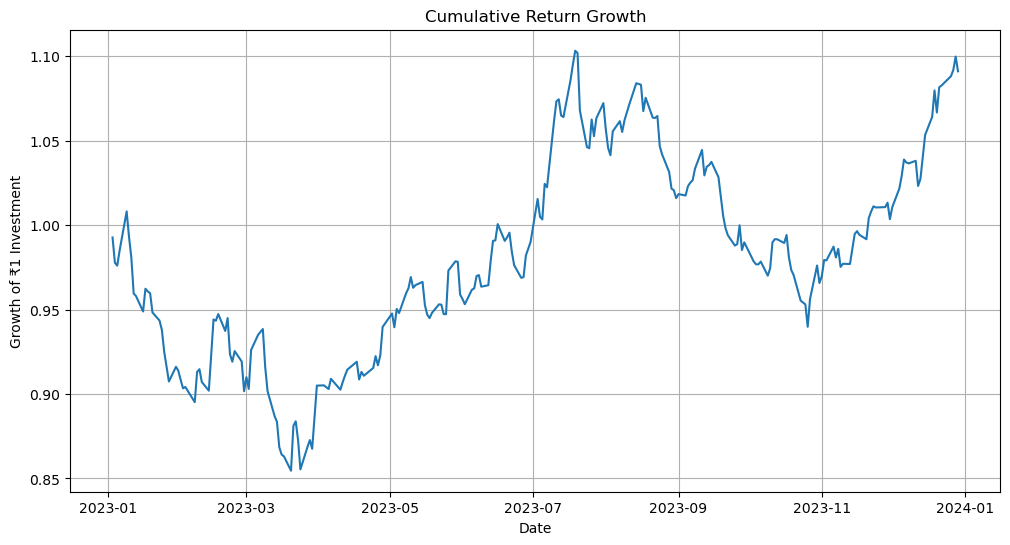

In [49]:
df['Cumulative_Return'] = (1 + df['Daily_Returns']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Cumulative_Return'])
plt.title("Cumulative Return Growth")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1 Investment")
plt.grid(True)
plt.show()

### 📈 Interpretation: Cumulative Return Growth

The cumulative return plot shows how ₹1 invested at the beginning of the period would have grown over time.

Key Observation:
- An upward curve indicates overall wealth creation.
- Periods of stagnation reflect sideways market movement.
- Temporary dips represent drawdowns during volatile phases.

This provides a long-term investment perspective beyond daily fluctuations.

In [52]:
df["Mean_Return"] = df["Daily_Returns"].mean()
df["Daily_Sharpe"] = mean_return / df["Daily_Returns"].std()
df["Annualized_Sharpe"] = Daily_sharpe * np.sqrt(252)
df['Rolling_vol'] = df['Close'].rolling(window = 21).std()

In [54]:
df["Moving_Avg_20"] = df["Close"].rolling(window = 20).mean()
df["Moving_Avg_50"] = df["Close"].rolling(window = 50).mean()

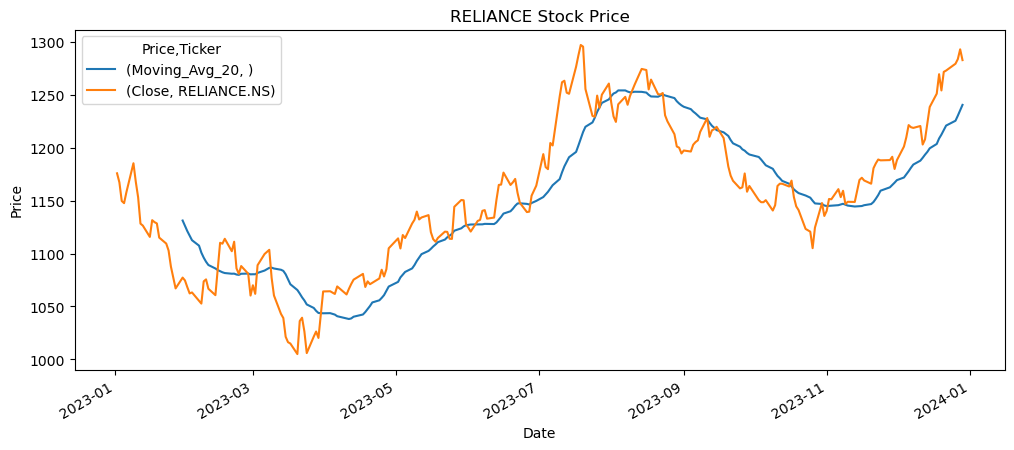

In [56]:
df[['Moving_Avg_20','Close']].plot(figsize=(12,5))
plt.title('RELIANCE Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [58]:
### Create buy/ Sell Signals

df['Signal']= 0
df.loc[df['Moving_Avg_20'] > df['Moving_Avg_50'], 'Signal'] = 1

### Detect Crossover

df['position'] = df['Signal'].diff()
df[['Moving_Avg_20','Moving_Avg_50', 'Signal',"position"]].tail(100)

Price,Moving_Avg_20,Moving_Avg_50,Signal,position
Ticker,,,,
Date,,,,
2023-08-03,1252.375647,1192.281531,1,0.0
2023-08-04,1254.322760,1194.828386,1,0.0
2023-08-07,1254.307922,1196.909094,1,0.0
2023-08-08,1253.240436,1198.710715,1,0.0
2023-08-09,1252.512610,1200.681982,1,0.0
...,...,...,...,...
2023-12-22,1221.051202,1180.764631,1,0.0
2023-12-26,1225.621130,1183.077512,1,0.0


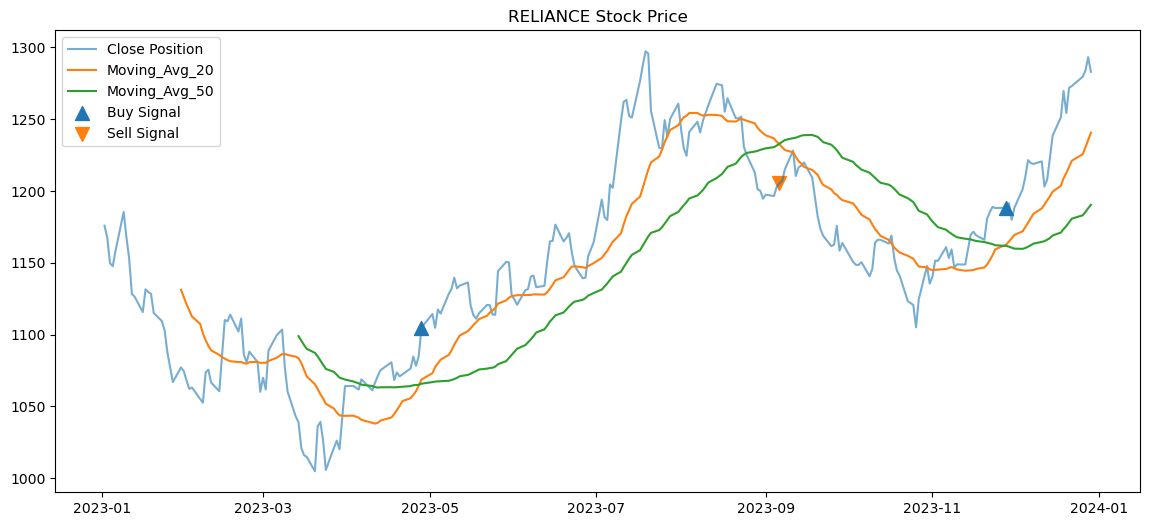

In [60]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Position',alpha =0.6)
plt.plot(df['Moving_Avg_20'], label='Moving_Avg_20',linewidth =1.5)
plt.plot(df['Moving_Avg_50'], label='Moving_Avg_50',linewidth =1.5)

plt.scatter(
    df[df['position'] == 1].index,
    df['Close'][df['position'] == 1],
    marker='^',
    s=100,
    label='Buy Signal'
)

plt.scatter(
    df[df['position'] == -1].index,
    df['Close'][df['position'] == -1],
    marker='v',
    s=100,
    label='Sell Signal'
)

plt.title('RELIANCE Stock Price')
plt.legend()
plt.show()

### **Download the multiple stocks for comperision**

In [63]:
stocks = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']
df2 = yf.download(stocks, start='2023-01-01', end='2024-01-01', group_by='ticker')
df2.head()

[*********************100%***********************]  3 of 3 completed


Ticker      RELIANCE.NS                                                   \
Price              Open         High          Low        Close    Volume   
Date                                                                       
2023-01-02  1164.066352  1177.304802  1163.244669  1175.889648   5316175   
2023-01-03  1170.936659  1174.565828  1163.062148  1167.284668   7658932   
2023-01-04  1167.261851  1169.110728  1147.632506  1149.709595   9264891   
2023-01-05  1151.969199  1157.858026  1143.067494  1147.655273  13637099   
2023-01-06  1153.407240  1163.130627  1149.595501  1158.086304   6349597   

Ticker     HDFCBANK.NS                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2023-01-02  782.859956  788.994845  778.794112  783.677917   4381378   
2023-01-03  780.550329  790.558642  780.550329  788.802368   8378030   
2023-01-04  786.709275  791.881828  773.236577  774.704163  10351600   
2023-01-05  777.085889  778.553474  764.768007  769.723999  10941436   
2023-01-06  770.830752  774.247032  759.378936  767.173889   9092462   

Ticker           TCS.NS                                                  
Price              Open         High          Low        Close   Volume  
Date                                                                     
2023-01-02  2932.389336  2937.649920  2909.189155  2932.793945   709547  
2023-01-03  2924.296376  2985.444024  2918.271578  2977.665771  1245178  
2023-01-04  2973.484221  2992.053455  2955.050003  2980.633057  1231668  
2023-01-05  2994.616327  3001.000949  2951.228470  2977.441162  1826057  
2023-01-06  2967.459470  2968.853320  2877.536455  2887.922607  2488376

#### **Group Analysis of 3 Different Stocks**

In [66]:
## Create an empty DataFrame to store just the returns
returns_df = pd.DataFrame()

# Loop through each stock in your list
for stock in stocks:
    # Calculate pct_change for the 'Close' column of each ticker
    returns_df[stock] = df2[stock]['Close'].pct_change()

print(returns_df.head())

            RELIANCE.NS    TCS.NS  HDFCBANK.NS
Date                                          
2023-01-02          NaN       NaN          NaN
2023-01-03    -0.007318  0.015300     0.006539
2023-01-04    -0.015056  0.000997    -0.017873
2023-01-05    -0.001787 -0.001071    -0.006428
2023-01-06     0.009089 -0.030066    -0.003313


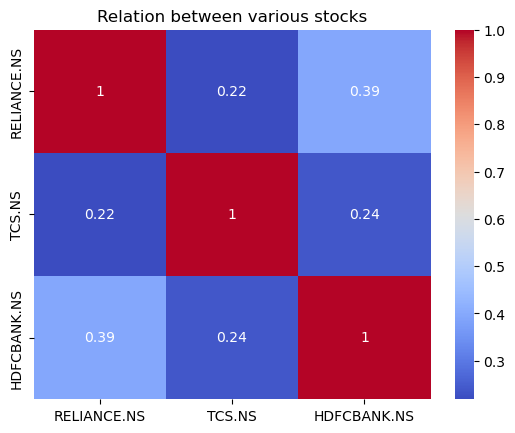

In [68]:
#### Analyse the co-relation

correlation = returns_df.corr()

#### Vilualize it with heat map

sns.heatmap(correlation, annot = True, cmap = "coolwarm")
plt.title("Relation between various stocks")
plt.show()

In [70]:
### Risk Vs Reward Summary

# Calculate basic stats
summary = pd.DataFrame()
summary['Annual_Return %'] = returns_df.mean() * 252 * 100
summary['Annual_Volatility %'] = returns_df.std() * (252**0.5) * 100
summary['Sharpe_Ratio'] = (returns_df.mean() / returns_df.std()) * (252**0.5)

print(summary.round(2))

             Annual_Return %  Annual_Volatility %  Sharpe_Ratio
RELIANCE.NS            10.51                17.42          0.60
TCS.NS                 20.87                18.18          1.15
HDFCBANK.NS             7.59                16.86          0.45


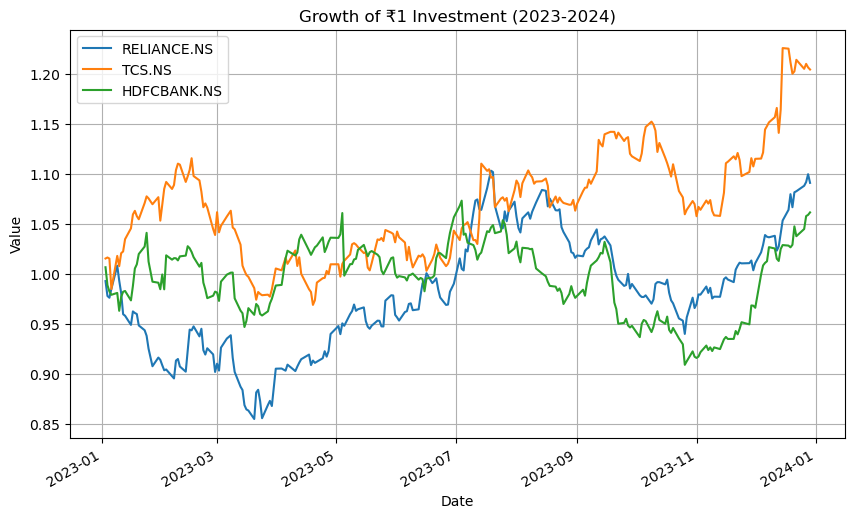

In [72]:
# Calculate cumulative returns starting from 1 (100% of investment)
cum_returns = (1 + returns_df).cumprod()

# Plot the results
cum_returns.plot(figsize=(10, 6))
plt.title('Growth of ₹1 Investment (2023-2024)')
plt.ylabel('Value')
plt.grid(True)
plt.show()

### **Calculate the MDD Maximum Drawdown**

In [75]:
### Step 1 Calculate the commulative Growth

cum_returns = (1 + returns_df).cumprod()

### Step 2 Calculate the running maximum 

running_max = cum_returns.cummax()

### Step 3 Calculate the Drawdown (Current Value VS Peak)

drawdown = (cum_returns - running_max) / running_max

### Step 4 Find the Maximum (Worst) Drawdown for each stock

max_drawdown = drawdown.min()

print("--- MAXIMUM DRAWDOWN (Worst Case Scenario) ---")
print((max_drawdown * 100).round(2).astype(str) + '%')

--- MAXIMUM DRAWDOWN (Worst Case Scenario) ---
RELIANCE.NS    -15.23%
TCS.NS         -13.17%
HDFCBANK.NS    -15.32%
dtype: object


In [77]:
summary['Annual_Return %'] = returns_df.mean() * 252 * 100
summary['Annual_Volatility %'] = returns_df.std() * (252**0.5) * 100
summary['Sharpe_Ratio'] = (returns_df.mean() / returns_df.std()) * (252**0.5)
summary['max_drawdown'] = drawdown.min()*100
print(summary.round(2))

             Annual_Return %  Annual_Volatility %  Sharpe_Ratio  max_drawdown
RELIANCE.NS            10.51                17.42          0.60        -15.23
TCS.NS                 20.87                18.18          1.15        -13.17
HDFCBANK.NS             7.59                16.86          0.45        -15.32


### **Calculate the recovery period** 

In [80]:
def get_max_recovery_days(series):
    # A value is 'underwater' if drawdown is less than 0
    is_underwater = series < 0
    
    # We identify groups of consecutive 'True' values
    # (This is a pro trick using 'cumsum' to create unique IDs for each streak)
    streaks = is_underwater.ne(is_underwater.shift()).cumsum()
    
    # We count the length of each streak and find the biggest one
    # Only for the periods where the stock was actually underwater
    underwater_streaks = streaks[is_underwater]
    
    if underwater_streaks.empty:
        return 0
    
    return underwater_streaks.value_counts().max()

# Apply the function to each stock in your drawdown DataFrame
recovery_times = drawdown.apply(get_max_recovery_days)

print("--- LONGEST UNDERWATER PERIOD (In Trading Days) ---")
print(recovery_times)

--- LONGEST UNDERWATER PERIOD (In Trading Days) ---
RELIANCE.NS    116
TCS.NS         139
HDFCBANK.NS    121
dtype: int64


In [82]:
summary['Annual_Return %'] = returns_df.mean() * 252 * 100
summary['Annual_Volatility %'] = returns_df.std() * (252**0.5) * 100
summary['Sharpe_Ratio'] = (returns_df.mean() / returns_df.std()) * (252**0.5)
summary['max_drawdown'] = drawdown.min()*100
summary['recovery_times'] = drawdown.apply(get_max_recovery_days)
print(summary.round(2))

             Annual_Return %  Annual_Volatility %  Sharpe_Ratio  max_drawdown  \
RELIANCE.NS            10.51                17.42          0.60        -15.23   
TCS.NS                 20.87                18.18          1.15        -13.17   
HDFCBANK.NS             7.59                16.86          0.45        -15.32   

             recovery_times  
RELIANCE.NS             116  
TCS.NS                  139  
HDFCBANK.NS             121  


### **Prediction of Price Using ML ( Machine Learning)**

In [85]:
### Linear Regression for price prediction.

import datetime as dt
from sklearn.linear_model import LinearRegression

In [87]:
### Change the Date into integers so that i could be fit into the prediction model

df_tcs = df2['TCS.NS'].copy().dropna()
df_tcs['Date_Ordinal'] = pd.to_datetime(df_tcs.index).map(dt.datetime.toordinal)

In [89]:
### Define the X (Features) & Y (targets)

X = df_tcs['Date_Ordinal'].values.reshape(-1, 1)
y = df_tcs['Close'].values

In [91]:
### Train & Test the model

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [93]:
### Create & Train the model

Model1 = LinearRegression()
Model1.fit(X_train, y_train)

LinearRegression()

In [95]:
### Make Predictions & Evaluate

predictions1 = Model1.predict(X_test)

In [97]:
### Check the accuracy of the model

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, predictions1))

print(f"On average, the model is off by: ₹{rmse:.2f}")

On average, the model is off by: ₹148.06


In [99]:
# Create dates for the next 30 days
last_date = df_tcs.index[-1]
future_dates = [last_date + dt.timedelta(days=i) for i in range(1, 31)]
future_ordinals = np.array([d.toordinal() for d in future_dates]).reshape(-1, 1)

# Predict!
future_preds = Model1.predict(future_ordinals)

print(f"Predicted Price for {future_dates[-1].date()}: ₹{future_preds[-1]:.2f}")

Predicted Price for 2024-01-28: ₹3300.19


In [101]:
### Calculate the error percentage (MAPE)

## Calculate the average price of the test set

avg_price = y_test.mean()

## Calculate the error percentage error

error_pct= (rmse / avg_price)*100

print(f"avg_price: ₹{avg_price:.2f}")
print(f"Prediction Error: {error_pct:.2f}%")

avg_price: ₹3294.92
Prediction Error: 4.49%


In [103]:
### The R square score (cofficient of determination)

from sklearn.metrics import r2_score 
r2 = r2_score(y_test, predictions1)
print(f"R-squared Score: {r2: .4f}")

R-squared Score:  0.0864


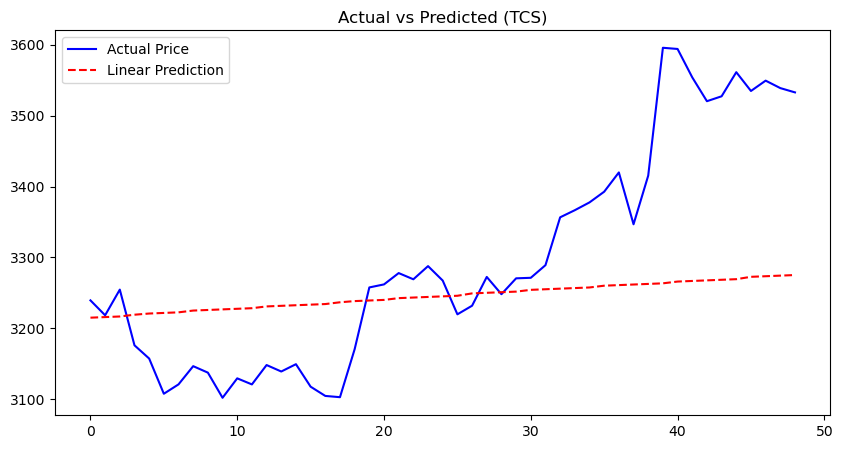

In [105]:
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='Actual Price', color='blue')
plt.plot(predictions1, label='Linear Prediction', color='red', linestyle='--')
plt.title('Actual vs Predicted (TCS)')
plt.legend()
plt.show()

#### **Time series Analysis**

In [110]:
### ARIMA MODEL for prediction of stock closing price
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [112]:
result= adfuller(df_tcs['Close'])

In [114]:
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] <= 0.05:
    print("Data is stationary (Ready for ARIMA)")
else:
    print("Data is NOT stationary (We need to 'difference' it)")

ADF Statistic: -1.094430297676601
p-value: 0.7172879193270871
Data is NOT stationary (We need to 'difference' it)


In [116]:
# Create a differenced series (Today's Price - Yesterday's Price)
df_diff = df_tcs['Close'].diff().dropna()

# Check the test again on the differenced data
result_diff = adfuller(df_diff)
print(f'New p-value: {result_diff[1]}')

New p-value: 1.7303015496717022e-28


In [120]:
from statsmodels.tsa.arima.model import ARIMA

# Let's start with a standard (1, 1, 1) setup
# 'order' is (p, d, q)
model = ARIMA(df_tcs['Close'], order=(1, 1, 1))
model_fit = model.fit()

# View the summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  245
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1220.357
Date:                Mon, 23 Feb 2026   AIC                           2446.714
Time:                        23:02:52   BIC                           2457.206
Sample:                             0   HQIC                          2450.940
                                - 245                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0088     42.379     -0.000      1.000     -83.070      83.052
ma.L1          0.0105     42.363      0.000      1.000     -83.019      83.040
sigma2      1293.4715     88.611     14.597      0.0

C:\Users\Bhanu\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Bhanu\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Bhanu\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Bhanu\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

In [122]:
# Predict the last 10 days to compare with actuals
forecast = model_fit.forecast(steps=10)
print(forecast)

245    3532.868635
246    3532.868725
247    3532.868724
248    3532.868724
249    3532.868724
250    3532.868724
251    3532.868724
252    3532.868724
253    3532.868724
254    3532.868724
Name: predicted_mean, dtype: float64


C:\Users\Bhanu\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bhanu\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
